In [1]:
#SHRAVANI.P.DESHPANDE_1032222493

In [2]:
#NLP LCA 2
#Problem Statement : 36) Analyze word frequency distribution across BBC vs Reuters.

In [3]:
#Installing and importing libraries
!pip install nltk pandas matplotlib

import nltk
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os
import string
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In this step I have installed and imported all the required libraries for performing Natural Language Processing and data analysis. The NLTK library is used for NLP tasks such as tokenization, stopword removal, and lemmatization. Pandas is used to load and manage the dataset, while Matplotlib is used to create visualizations for comparing word frequency distributions. Additional libraries such as os, string, and collections help in handling files, cleaning text, and counting word frequencies.

In [5]:
#I have uploaded the datasets in zip as it is , so unzipping in this step
# Unzip BBC dataset
with zipfile.ZipFile("BBC.zip", 'r') as zip_ref:
    zip_ref.extractall("BBC")

# Unzip Reuters dataset
with zipfile.ZipFile("Reuters.zip", 'r') as zip_ref:
    zip_ref.extractall("Reuters")

print("Datasets extracted successfully")

Datasets extracted successfully


The BBC and Reuters datasets were uploaded in compressed ZIP format. In this step, I extracted the datasets using Python’s zipfile module. This makes the dataset files accessible for further processing and analysis in the Colab environment.

In [11]:
#Loading BBC Dataset (CSV)
BBC_df = pd.read_csv("/content/Reuters/bbc_news.csv")

print(BBC_df.head())
print("Total BBC Articles:", len(BBC_df))

                                               title  \
0  Ukraine: Angry Zelensky vows to punish Russian...   
1  War in Ukraine: Taking cover in a town under a...   
2         Ukraine war 'catastrophic for global food'   
3  Manchester Arena bombing: Saffie Roussos's par...   
4  Ukraine conflict: Oil price soars to highest l...   

                         pubDate  \
0  Mon, 07 Mar 2022 08:01:56 GMT   
1  Sun, 06 Mar 2022 22:49:58 GMT   
2  Mon, 07 Mar 2022 00:14:42 GMT   
3  Mon, 07 Mar 2022 00:05:40 GMT   
4  Mon, 07 Mar 2022 08:15:53 GMT   

                                               guid  \
0  https://www.bbc.co.uk/news/world-europe-60638042   
1  https://www.bbc.co.uk/news/world-europe-60641873   
2      https://www.bbc.co.uk/news/business-60623941   
3            https://www.bbc.co.uk/news/uk-60579079   
4      https://www.bbc.co.uk/news/business-60642786   

                                                link  \
0  https://www.bbc.co.uk/news/world-europe-606380...   
1  

In this step, I loaded the BBC news dataset into a Pandas DataFrame using the read_csv() function. The dataset contains multiple columns such as title, publication date, link, and description. The head() function displays the first few rows to verify that the dataset has been loaded correctly, and the total number of articles is printed to understand the dataset size.

In [14]:
#Preprocessing Function (Tokenization + Stopwords + Lemmatization)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    tokens = word_tokenize(text.lower())

    clean_tokens = []

    for word in tokens:
        if word not in stop_words and word not in string.punctuation and word.isalpha():

            word = lemmatizer.lemmatize(word)

            clean_tokens.append(word)

    return clean_tokens

Text preprocessing is an important step in Natural Language Processing. In this step, a function is created to clean and normalize the text data. The preprocessing process includes:

Tokenization: Splitting text into individual words

Lowercasing: Converting all words to lowercase for uniformity

Stopword Removal: Removing commonly used words such as the, is, and, which do not carry significant meaning

Punctuation Removal: Eliminating punctuation symbols

Lemmatization: Converting words into their base or root form

These steps ensure that the dataset contains only meaningful words for frequency analysis.

In [18]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

NLTK requires certain linguistic resources for performing tasks such as tokenization and lemmatization. In this step, the necessary resources including punkt tokenizer, stopword lists, and WordNet lexical database are downloaded. These resources enable the preprocessing function to work correctly.

In [19]:
#Processing BBC Dataset
bbc_tokens = []

for i,row in BBC_df.iterrows():

    text = str(row['title']) + " " + str(row['description'])

    tokens = preprocess(text)

    bbc_tokens.extend(tokens)

bbc_freq = Counter(bbc_tokens)

print("Top 20 BBC Words:")
print(bbc_freq.most_common(20))

Top 20 BBC Words:
[('say', 8579), ('england', 4029), ('world', 3931), ('uk', 3199), ('new', 3184), ('bbc', 3028), ('year', 2990), ('cup', 2915), ('win', 2880), ('first', 2708), ('ukraine', 2686), ('woman', 2632), ('people', 2462), ('u', 2446), ('day', 2289), ('league', 2024), ('police', 1895), ('war', 1891), ('two', 1850), ('one', 1821)]


In this step, the BBC dataset is processed to extract meaningful words for analysis. The title and description columns are combined to form the complete text of each article. The preprocessing function is applied to clean the text, and the resulting tokens are stored in a list. The Counter() function is then used to compute the frequency of each word in the dataset. Finally, the top 20 most frequent words in the BBC dataset are displayed.

In [20]:
#Loading Reuters Articles
reuters_tokens = []

base_path = "/content/BBC/reuters/reuters/reuters"

for root, dirs, files in os.walk(base_path):

    for file in files:

        file_path = os.path.join(root,file)

        try:

            with open(file_path,'r',encoding='latin-1') as f:

                text = f.read()

                tokens = preprocess(text)

                reuters_tokens.extend(tokens)

        except:
            continue

reuters_freq = Counter(reuters_tokens)

print("Top 20 Reuters Words:")
print(reuters_freq.most_common(20))

Top 20 Reuters Words:
[('said', 25382), ('mln', 18598), ('v', 14358), ('dlrs', 12329), ('pct', 9771), ('lt', 8696), ('ct', 8519), ('year', 7568), ('net', 6986), ('billion', 5817), ('share', 5736), ('company', 5524), ('loss', 5521), ('would', 4691), ('bank', 4620), ('shr', 4131), ('earn', 4024), ('price', 3985), ('inc', 3931), ('market', 3599)]


Unlike the BBC dataset, the Reuters dataset contains news articles stored as individual text files inside folders. In this step, the program navigates through all folders and files using the os.walk() function. Each file is opened and its content is read. The preprocessing function is then applied to clean the text and extract meaningful words. All processed tokens are stored, and the Counter() function is used to calculate the word frequency distribution for the Reuters dataset.

In [21]:
#Comparing Top Words
bbc_top = dict(bbc_freq.most_common(10))
reuters_top = dict(reuters_freq.most_common(10))

print("BBC Top Words:",bbc_top)
print("Reuters Top Words:",reuters_top)

BBC Top Words: {'say': 8579, 'england': 4029, 'world': 3931, 'uk': 3199, 'new': 3184, 'bbc': 3028, 'year': 2990, 'cup': 2915, 'win': 2880, 'first': 2708}
Reuters Top Words: {'said': 25382, 'mln': 18598, 'v': 14358, 'dlrs': 12329, 'pct': 9771, 'lt': 8696, 'ct': 8519, 'year': 7568, 'net': 6986, 'billion': 5817}


After calculating the frequency distribution for both datasets, the top 10 most frequent words are extracted from each dataset. These words provide insights into the most commonly used vocabulary in BBC and Reuters articles. The results are printed to allow comparison between the two news sources.

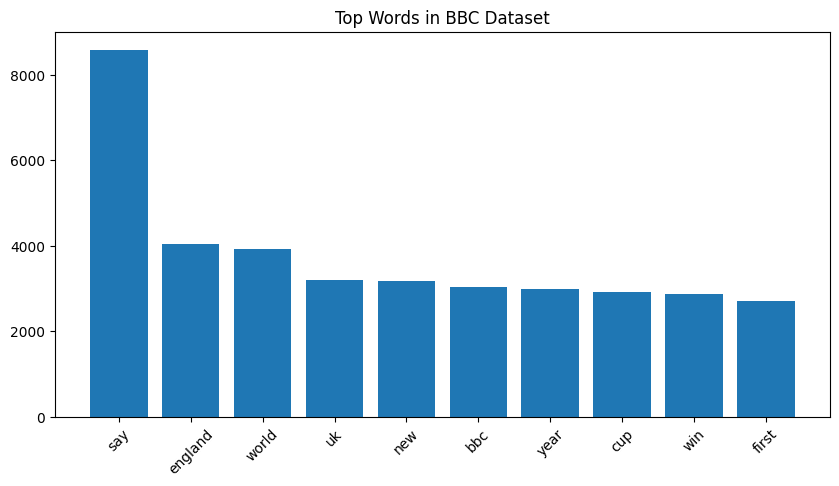

In [22]:
#Plotting BBC Word Frequency
plt.figure(figsize=(10,5))

plt.bar(bbc_top.keys(),bbc_top.values())

plt.title("Top Words in BBC Dataset")

plt.xticks(rotation=45)

plt.show()

In this step, a bar chart is created to visualize the most frequent words in the BBC dataset. Visualization helps in easily identifying which words appear most often in BBC news articles. The x-axis represents the words, while the y-axis represents their frequency.

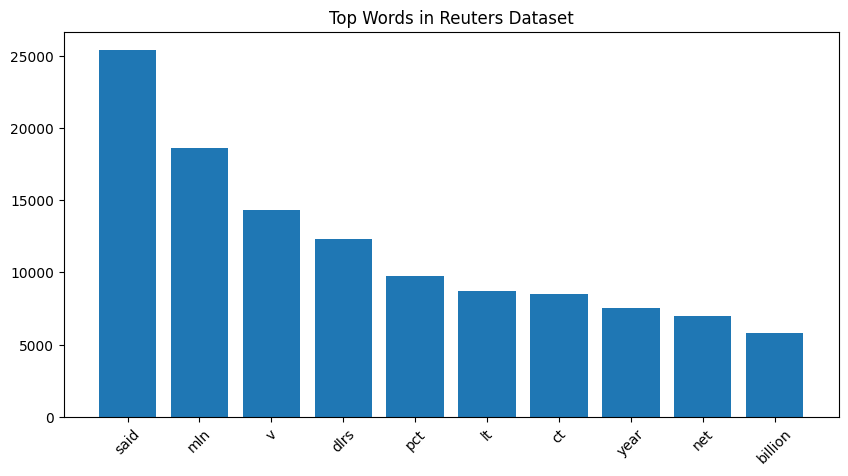

In [23]:
#Plotting Reuters Word Frequency
plt.figure(figsize=(10,5))

plt.bar(reuters_top.keys(),reuters_top.values())

plt.title("Top Words in Reuters Dataset")

plt.xticks(rotation=45)

plt.show()

This step generates a bar chart to visualize the most frequently occurring words in the Reuters dataset. By plotting these frequencies, we can observe the dominant terms used in Reuters articles and compare them with those found in the BBC dataset.

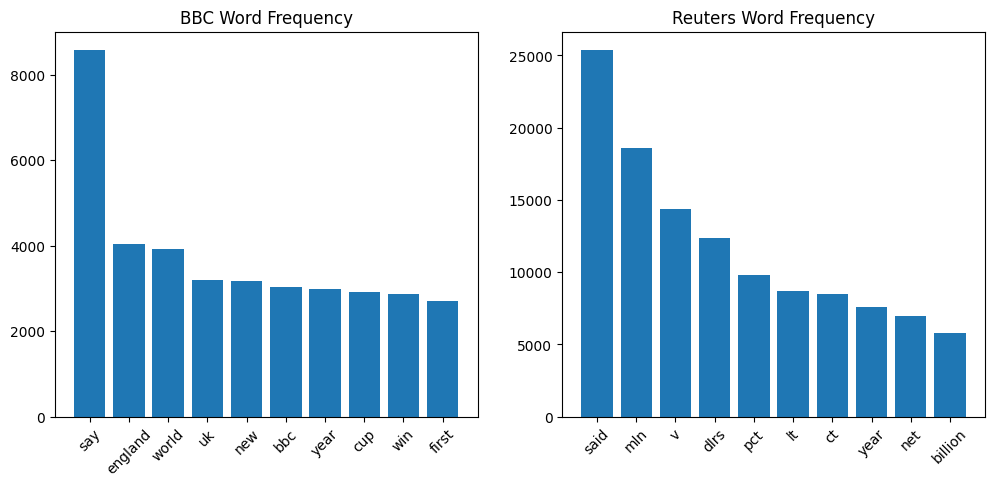

In [24]:
#Combined Comparison Graph
bbc_words,bbc_counts = zip(*bbc_freq.most_common(10))
reuters_words,reuters_counts = zip(*reuters_freq.most_common(10))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(bbc_words,bbc_counts)
plt.title("BBC Word Frequency")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.bar(reuters_words,reuters_counts)
plt.title("Reuters Word Frequency")
plt.xticks(rotation=45)

plt.show()

This step creates a side-by-side comparison graph showing the top 10 words from both the BBC and Reuters datasets. The visualization allows easy comparison of the vocabulary patterns between the two datasets. Differences in word usage highlight the varying focus of the two news sources, where BBC covers broader public news topics while Reuters often emphasizes financial and economic reporting.